# The .......: Uncovering the Relative Age Effect
### A Data-Driven Study of International Rugby and Cricket Squads

# Introduction
In the mid 1980s the Relative Age Effect phenomenon was born. RAE is the phenomenon that children born earlier in the selection year have a higher likelihood of participation and success compared to those born later on in the seletion year. However, does this actually have an effect at the very highest level of international sports? 


In [171]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Set a style
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = "Arial"

path_eng_cricket = "data/clean/england_cricket_squad_clean.csv"
path_sa_rugby = "data/clean/south_africa_squad_clean.csv"
path_sa_cricket = "data/clean/south_africa_cricket_squad_clean.csv"
path_eng_rugby = "data/clean/england_squad_clean.csv"

print("Style set to Seaborn whitegrid and font set to Arial")

Style set to Seaborn whitegrid and font set to Arial


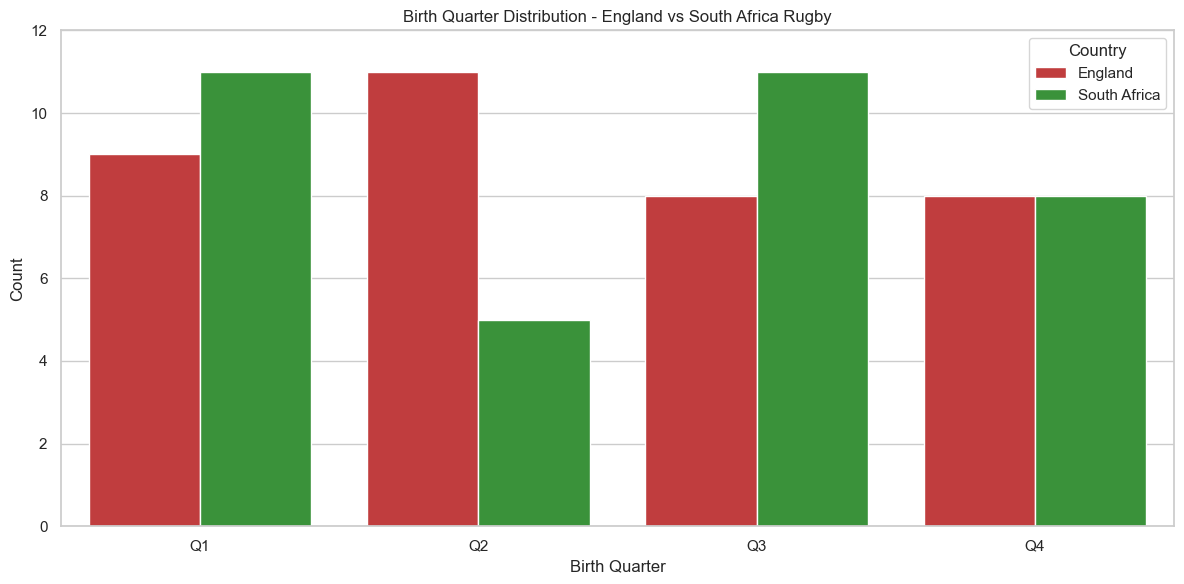

In [182]:
eng_rugby = pd.read_csv(path_eng_rugby)
sa_rugby = pd.read_csv(path_sa_rugby)

eng_rugby["Country"] = "England"
sa_rugby["Country"] = "South Africa"

combined_rugby = pd.concat([eng_rugby, sa_rugby])

# Create a single figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot combined data with countries shown by hue (color)
sns.countplot(ax=ax, data=combined_rugby, x='Birth Quarter', hue='Country', 
              order=['Q1', 'Q2', 'Q3', 'Q4'], 
              palette={'England': '#d62728', 'South Africa': '#2ca02c'})  # Red and green
ax.set_title('Birth Quarter Distribution - England vs South Africa Rugby')
ax.set_xlabel('Birth Quarter')
ax.set_ylabel('Count')
ax.set_ylim(0, 12)
plt.tight_layout()
plt.show()

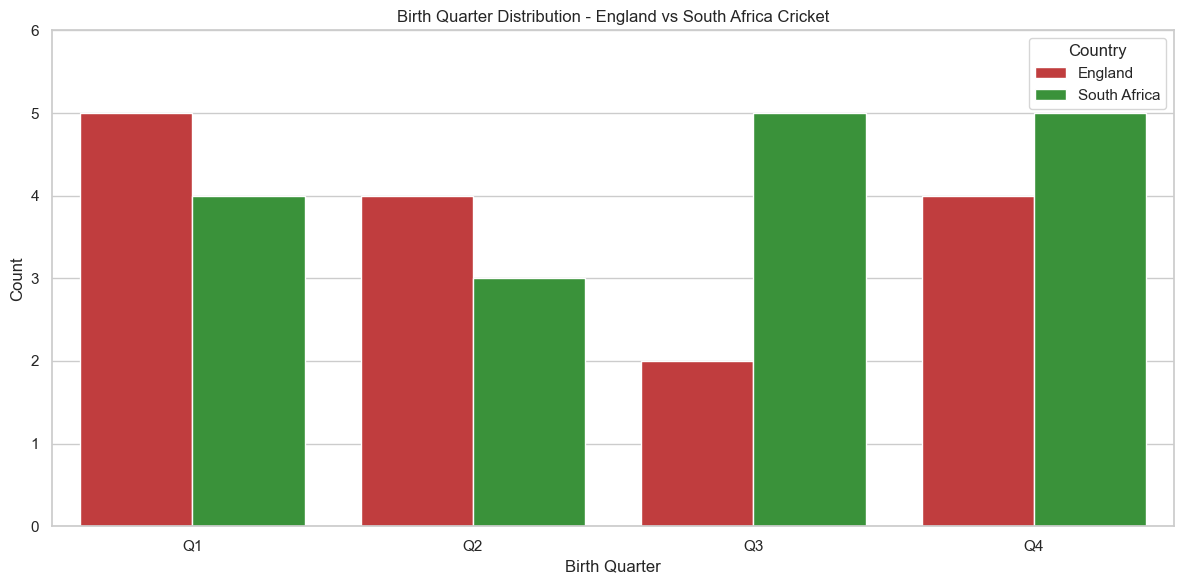

In [173]:
eng_cricket = pd.read_csv(path_eng_cricket)
sa_cricket = pd.read_csv(path_sa_cricket)

eng_cricket["Country"] = "England"
sa_cricket["Country"] = "South Africa"

combined_cricket = pd.concat([eng_cricket, sa_cricket])

# Create a single figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot combined data with countries shown by hue (color)
sns.countplot(ax=ax, data=combined_cricket, x='Birth Quarter', hue='Country', 
              order=['Q1', 'Q2', 'Q3', 'Q4'], 
              palette={'England': '#d62728', 'South Africa': '#2ca02c'})  # Red and green
ax.set_title('Birth Quarter Distribution - England vs South Africa Cricket')
ax.set_xlabel('Birth Quarter')
ax.set_ylabel('Count')
ax.set_ylim(0, 6)
plt.tight_layout()
plt.show()


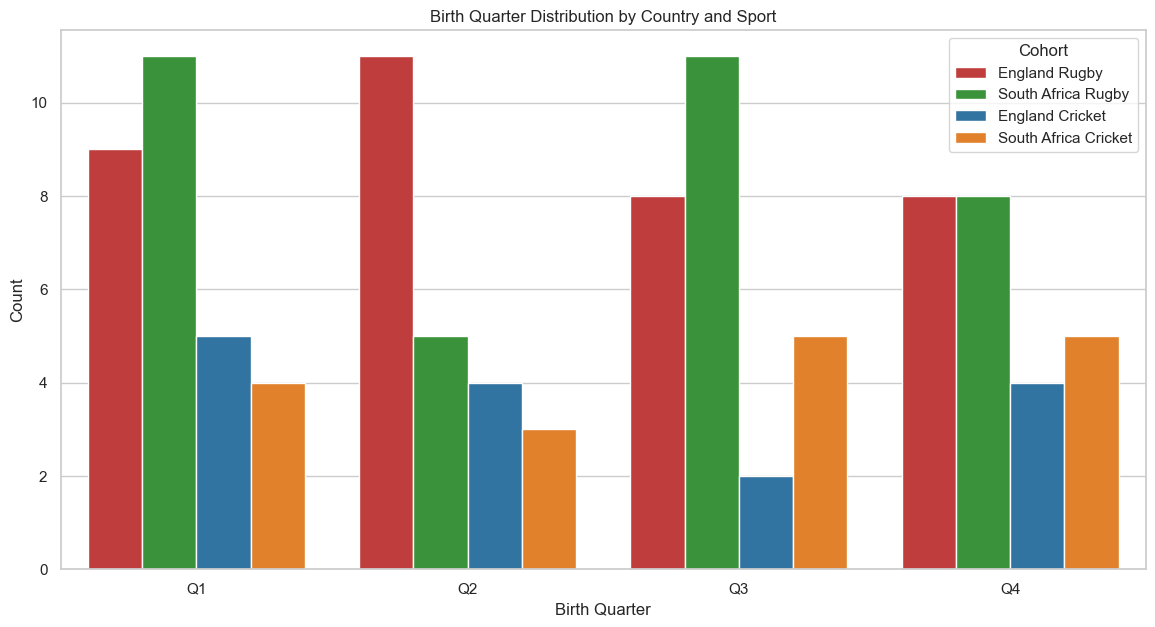

In [174]:
# Create a single "Master" dataframe for rugby and cricket combined
eng_rugby["Sport"] = "Rugby"
sa_rugby["Sport"] = "Rugby"
eng_cricket["Sport"] = "Cricket"
sa_cricket["Sport"] = "Cricket"

# Standardise names and combine
df_master = pd.concat([eng_rugby, sa_rugby, eng_cricket, sa_cricket])

# Ensure Quarter_Num exists and is numeric for plotting
df_master['Quarter_Num'] = df_master['Birth Quarter'].str.extract('Q([1-4])').astype(int)

#Create a "Cohort" name for easy grouping
df_master['Cohort'] = df_master['Country'] + ' ' + df_master['Sport']

# Plot combined data with countries and sports shown by hue (color)
plt.figure(figsize=(14, 7))
sns.countplot(data=df_master, x='Birth Quarter', hue='Cohort', 
              order=['Q1', 'Q2', 'Q3', 'Q4'], 
              palette={'England Rugby': '#d62728', 'South Africa Rugby': '#2ca02c',
                       'England Cricket': '#1f77b4', 'South Africa Cricket': '#ff7f0e'})  # Red, green, blue, orange
plt.title('Birth Quarter Distribution by Country and Sport')
plt.xlabel('Birth Quarter')
plt.ylabel('Count')     
plt.show()



/var/folders/v7/719zp_bd3y14xtwqhz4p9plh0000gn/T/ipykernel_34121/1873572401.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=quarter_counts.index, y=quarter_counts.values, ax=ax, palette=['#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4'])


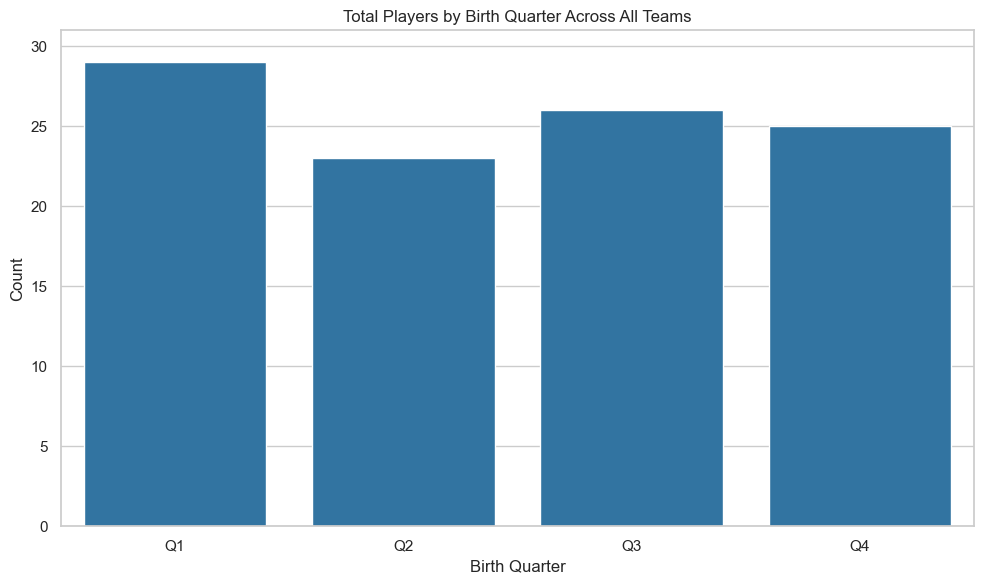

In [175]:
# Aggregate total counts across all teams by quarter
quarter_counts = df_master.groupby('Birth Quarter').size().reindex(['Q1', 'Q2', 'Q3', 'Q4'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=quarter_counts.index, y=quarter_counts.values, ax=ax, palette=['#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4'])
ax.set_title('Total Players by Birth Quarter Across All Teams')
ax.set_xlabel('Birth Quarter')
ax.set_ylabel('Count')
ax.set_ylim(0, quarter_counts.max() + 2)
plt.tight_layout()
plt.show()

In [176]:
# Calculate months since cutoff
def get_month_dist(row):
    # England starts in Sept (9), South Africa starts in Jan (1)
    start_month = 9 if row['Country'] == 'England' else 1

    #Get the month as a number 1-12
    month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
                 'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
    month_num = month_map.get(row['Birth Month'], np.nan)

    return (month_num - start_month) % 12

df_master["Months_Since_Cutoff"] = df_master.apply(get_month_dist, axis=1)


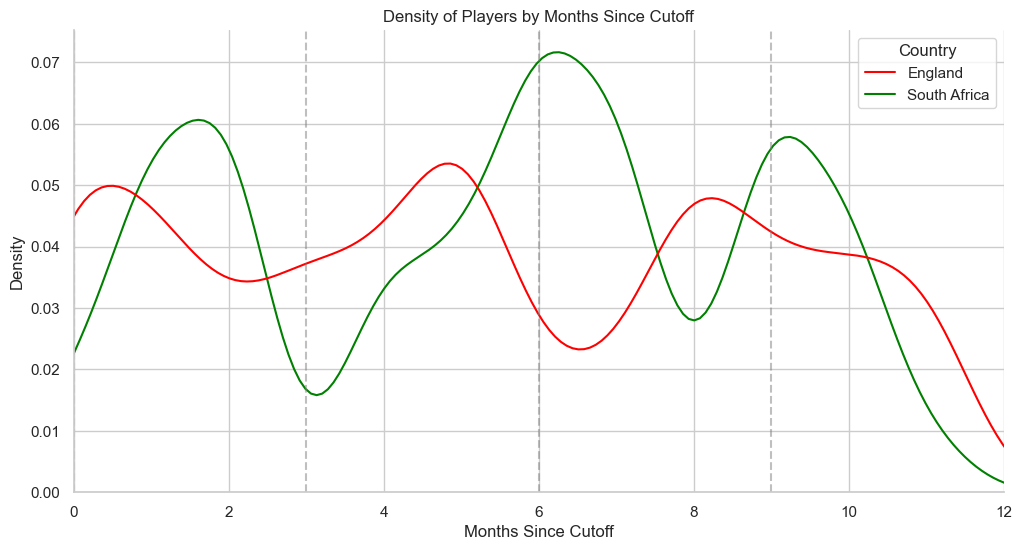

In [177]:
plt.figure(figsize=(12, 6))

#Use a lower bw_adjust to make the KDE more sensitive to the data distribution
sns.kdeplot(data=df_master, x='Months_Since_Cutoff', hue='Country', bw_adjust=0.4, palette={'England': 'red', 'South Africa': 'green'})

# Add the Quarter makrers ( Vertical lines at 0, 3, 6, 9)
for x in [0, 3, 6, 9]:
    plt.axvline(x=x, color='gray', linestyle='--', alpha=0.5)

plt.title('Density of Players by Months Since Cutoff')
plt.xlabel('Months Since Cutoff')
plt.xlim(0,12)
sns.despine()
plt.show()

In [178]:
from datetime import datetime

def calculate_relative_age(row):
    try:
        month_map = {
            'January': 1, 'February': 2, 'March': 3,
            'April': 4, 'May': 5, 'June': 6,
            'July': 7, 'August': 8, 'September': 9,
            'October': 10, 'November': 11, 'December': 12
        }

        month_num = month_map.get(row['Birth Month'])
        if month_num is None or pd.isna(row['Birth Day']):
            return None

        day = int(row['Birth Day'])
        birth_date = datetime(2000, month_num, day)

        if row['Country'] == 'England':
            cutoff_date = datetime(2000, 9, 1)
        else:
            cutoff_date = datetime(2000, 1, 1)

        delta_days = (birth_date - cutoff_date).days
        if delta_days < 0:
            delta_days += 366

        # Convert days to months (approximate: 30.44 days per month)
        delta_months = delta_days / 30.44
        return delta_months
    except Exception as e:
        print(f"Error calculating relative age for row: {row} - {e}")
        return None


df_master['Relative Age'] = df_master.apply(calculate_relative_age, axis=1)


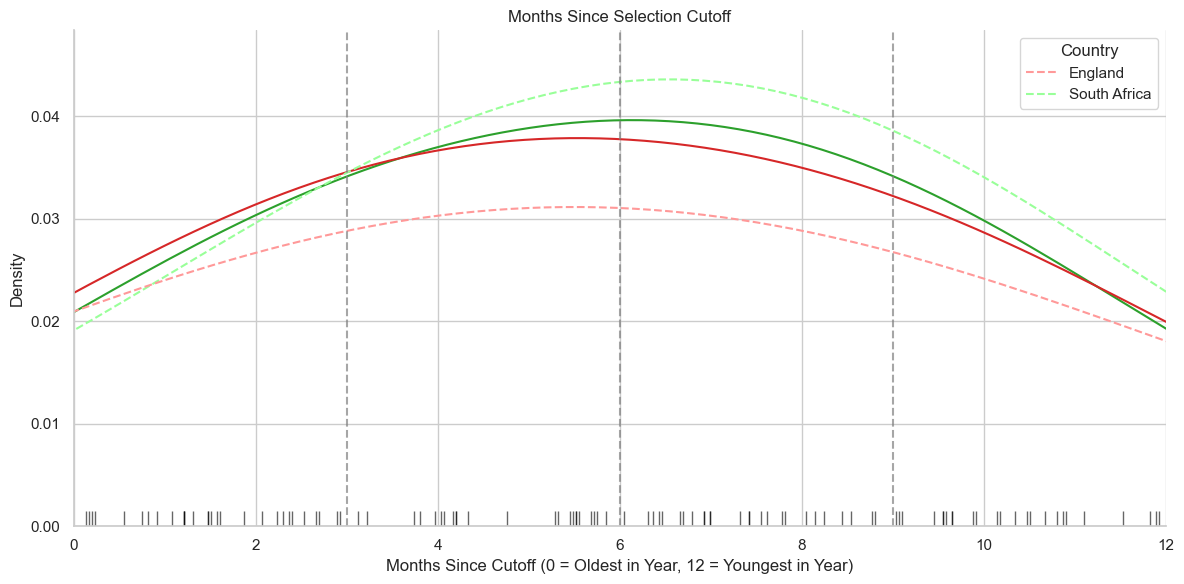

In [179]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Rugby (solid lines)
rugby_data = df_master[df_master['Sport'] == 'Rugby']
sns.kdeplot(data=rugby_data, x='Relative Age', hue='Country', fill=False, bw_adjust=2.0, 
            palette={'England': '#d62728', 'South Africa': '#2ca02c'}, ax=ax, linestyle='-')

# Plot Cricket (dashed lines)
cricket_data = df_master[df_master['Sport'] == 'Cricket']
sns.kdeplot(data=cricket_data, x='Relative Age', hue='Country', fill=False, bw_adjust=2.0, 
            palette={'England': '#ff9999', 'South Africa': '#99ff99'}, ax=ax, linestyle='--')

# Add vertical lines for quarter boundaries
ax.axvline(x=3, color='gray', linestyle='--', alpha=0.7, label='Q1/Q2 boundary')
ax.axvline(x=6, color='gray', linestyle='--', alpha=0.7, label='Q2/Q3 boundary')
ax.axvline(x=9, color='gray', linestyle='--', alpha=0.7, label='Q3/Q4 boundary')

# Add rug plot to show each player's relative age
player_points = df_master.dropna(subset=['Relative Age'])
sns.rugplot(data=player_points, x='Relative Age', height=0.03, color='black', alpha=0.6, ax=ax)

ax.set_ylabel('Density')
ax.set_title('Months Since Selection Cutoff')
ax.set_xlabel('Months Since Cutoff (0 = Oldest in Year, 12 = Youngest in Year)')
ax.set_xlim(0, 12)
sns.despine()
plt.tight_layout()
plt.show()


In [181]:
def perform_complete_analysis(df, label):
    # Prepate the data: Count Players per month (0-11
    counts = df['Months_Since_Cutoff'].value_counts().reset_index().reindex(range(12), fill_value=0)
    counts.columns = ['Months_Since_Cutoff', 'Count']

    # Fill in any months with zero counts to ensure all months are represented
    all_months = pd.DataFrame({'Months_Since_Cutoff': range(12)})
    counts = all_months.merge(counts, on='Months_Since_Cutoff', how='left').fillna(0)

    # Linear regression (SLR)
    x = sm.add_constant(counts['Months_Since_Cutoff'])
    y = counts['Count']
    model_slr = sm.OLS(y, x).fit()

    # Poisson Regression (IRR)
    model_poi = sm.GLM(y, x, family=sm.families.Poisson()).fit()
    irr = np.exp(model_poi.params['Months_Since_Cutoff'])

    # Results Output
    return {
        'label': label,
        'slope': model_slr.params['Months_Since_Cutoff'],
        'P-value': model_slr.pvalues['Months_Since_Cutoff'],
        'R-squared': model_slr.rsquared,
        'IRR': irr,
        'Percent_Drop': (irr - 1) * 100
    }

# Run for all categories
results = []
results.append(perform_complete_analysis(df_master[df_master['Country'] == 'England'], 'England'))
results.append(perform_complete_analysis(df_master[df_master['Country'] == 'South Africa'], 'South Africa'))
results.append(perform_complete_analysis(df_master, "All Players"))
results.append(perform_complete_analysis(df_master[df_master['Sport'] == 'Rugby'], "All Rugby Players"))
results.append(perform_complete_analysis(df_master[df_master['Sport'] == 'Cricket'], "All Cricket Players"))

# Covert into DataFrame for better display
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False)
)

              label     slope  P-value  R-squared      IRR  Percent_Drop
            England -0.087413 0.524757   0.041625 0.979622     -2.037823
       South Africa  0.122862 0.603770   0.025295 1.031130      3.113009
        All Players -0.094406 0.648289   0.021632 0.989058     -1.094163
  All Rugby Players -0.108392 0.480164   0.051040 0.981832     -1.816753
All Cricket Players  0.090909 0.485432   0.045231 1.037557      3.755676
